# Reranker Training with MLflow

Обучением LightGBM-реранкера с версионированием через MLflow и хранением артефактов в MinIO (S3).

## Инфраструктура
- **MLflow Tracking Server**: http://localhost:5050
- **MinIO S3 (артефакты)**: http://localhost:9000  (bucket: `mlflow-artifacts`)
- **MinIO Console**: http://localhost:9001  (login: `minioadmin` / `minioadmin`)

Запуск: 

`docker compose up -d` или `make dc.up`

## 0. Установка зависимостей

## 1. Импорты и настройка MLflow

In [1]:
import os
import io
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

import mlflow.lightgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    f1_score,
    confusion_matrix, 
    precision_score, 
    recall_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier




SEED = 42
np.random.seed(SEED)


In [43]:
import dotenv
dotenv.load_dotenv('../../.env')


MLFLOW_URI = os.getenv('MLFLOW_URI') # 'http://localhost:5050'
EXPERIMENT_NAME = os.getenv('EXPERIMENT_NAME') # 'reranker-lgbm'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment: {EXPERIMENT_NAME}')

MLflow tracking URI: http://localhost:5050
Experiment: reranker-lgbm


## 2. Загрузка и описание данных


Колонки:
- `idx` — позиция документа в выдаче
- `max`, `mean`, `std`, `perc_90` — агрегаты по скорам сходства
- `num_passed` — сколько порогов пройдено
- `range` — диапазон скоров
- `rel` — целевая метка релевантности (0/1)

In [3]:
DATA_PATH = '../../model/merged_for_boosting.csv'
if not os.path.exists(DATA_PATH):
    # Fallback: ищем рядом
    DATA_PATH = 'merged_for_boosting.csv'

df = pd.read_csv(DATA_PATH)

In [4]:
df.shape

(900, 9)

In [5]:
df['rel'].value_counts()

rel
0    746
1    154
Name: count, dtype: int64

In [6]:
df["rel"].mean()

np.float64(0.1711111111111111)

## Статистика признаков

In [7]:
df.describe()

,idx,max,mean,std,perc_90,num_passed,density,range,rel
count,900.00000,900.000000,900.000000,900.000000,900.000000,900.000000,900.0,900.000000,900.000000
mean,50.50000,0.244891,0.213998,0.015135,0.231558,89.267778,1.0,0.066413,0.171111
std,28.88212,0.018961,0.015228,0.005461,0.017357,99.203067,0.0,0.022018,0.376815
min,1.00000,0.206787,0.177417,0.004320,0.190063,9.000000,1.0,0.013672,0.000000
25%,25.75000,0.230957,0.203948,0.011188,0.219614,26.000000,1.0,0.051025,0.000000
50%,50.50000,0.241333,0.211245,0.014592,0.227649,65.000000,1.0,0.064697,0.000000
75%,75.25000,0.256348,0.221934,0.017662,0.240289,112.000000,1.0,0.081329,0.000000
max,100.00000,0.308838,0.276758,0.038066,0.293384,701.000000,1.0,0.140625,1.000000


In [8]:
print('NaN:', df.isnull().sum().sum())
print('Inf:', np.isinf(df.select_dtypes(include=np.number)).sum().sum())

NaN: 0
Inf: 0


## 3. Подготовка данных

In [9]:
FEATURES = ['max', 'mean', 'std', 'perc_90', 'num_passed', 'range']
TARGET = 'rel'

X = df[FEATURES]
y = df[TARGET]

# Train/val/test: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=SEED, 
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp,
    test_size=0.50, 
    random_state=SEED,
    stratify=y_temp
)


In [44]:
print(f'Train: {len(X_train)}')
print(f'Val: {len(X_val)}')
print(f'Test: {len(X_test)}')

Train: 630
Val: 135
Test: 135


In [46]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos

In [47]:
def find_best_threshold(model, X_v, y_v):
    """Подбор порога по максимальному F1 на валидации."""
    from sklearn.metrics import f1_score as _f1
    proba = model.predict_proba(X_v)[:, 1]
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (proba >= thr).astype(int)
        f = _f1(y_v, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    return round(best_thr, 2), round(best_f1, 4)


THRESHOLD = 0.5  # будет уточнён после обучения финальной модели


## 4. Baseline-модели

Для сравнения используем две простых базовые линии:
- **Majority класс** (всегда предсказывает 0 — не релевантно)
- **Decision Stump** (решающее дерево глубины 1, по одному признаку)

In [50]:
def eval_model(
    model, 
    X_tr, 
    y_tr, 
    X_v, 
    y_v, 
    X_te, 
    y_te, 
    name, 
    has_proba=True, 
    threshold=0.5,
):
    results = {}
    for split, Xs, ys in [('train', X_tr, y_tr), ('val', X_v, y_v), ('test', X_te, y_te)]:
        if has_proba:
            proba = model.predict_proba(Xs)[:, 1]
            auc = roc_auc_score(ys, proba)
            preds = (proba >= threshold).astype(int)
        else:
            auc = 0.5
            preds = model.predict(Xs)
        results[f'{split}_auc'] = auc
        results[f'{split}_f1'] = f1_score(ys, preds, zero_division=0)
        results[f'{split}_accuracy'] = accuracy_score(ys, preds)
    return results

### Dummy

In [51]:
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)
baseline_results = eval_model(dummy, X_train, y_train, X_val, y_val, X_test, y_test,
                               'Majority Baseline', has_proba=False)



### Decision Stump

In [52]:
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED)
stump.fit(X_train, y_train)
stump_thr, _ = find_best_threshold(stump, X_val, y_val)
stump_results = eval_model(stump, X_train, y_train, X_val, y_val, X_test, y_test,
                            'Decision Stump', threshold=stump_thr)
print(f'\nStump split: feature={FEATURES[stump.tree_.feature[0]]}, threshold={stump.tree_.threshold[0]:.4f}')



Stump split: feature=mean, threshold=0.2274


## 5. Выбор лучшей модели и обоснование

Сравниваем три конфигурации LightGBM + baseline. Лучшую фиксируем как финальную.

**Критерии выбора:**
- Основная метрика: **AUC** на validation (метрика для ранжирования, устойчива к дисбалансу)
- Дополнительно: F1 на тесте (баланс precision/recall важен при дисбалансе 4.8:1)
- Бизнес-критерий: минимальный overfitting (|train_auc - val_auc| < 0.05)

In [53]:
CONFIGS = {
    'lgbm_conservative': {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 15,
        'min_child_samples': 5,
        'min_child_weight': 0.001,
        'min_gain_to_split': 0.0,
        'min_data_in_leaf': 5,
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'random_state': SEED,
        'verbose': -1,
    },
    'lgbm_balanced': {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'min_child_samples': 10,
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'learning_rate': 0.03,
        'n_estimators': 500,
        'random_state': SEED,
        'verbose': -1,
    },
    'lgbm_dart': {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'dart',
        'num_leaves': 20,
        'min_child_samples': 5,
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'drop_rate': 0.1,
        'learning_rate': 0.05,
        'n_estimators': 200,
        'random_state': SEED,
        'verbose': -1,
    },
}



In [54]:
comparison_results = {}
best_thresholds = {}

for config_name, params in CONFIGS.items():
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)]
    )
    # Подбор порога по val для корректного F1
    thr, val_f1 = find_best_threshold(model, X_val, y_val)
    best_thresholds[config_name] = thr
    res = eval_model(model, X_train, y_train, X_val, y_val, X_test, y_test,
                     config_name, threshold=thr)
    res['overfitting'] = res['train_auc'] - res['val_auc']
    comparison_results[config_name] = (model, res)

/Users/andrey/PycharmProjects/vector-search-hse/.venv/lib/python3.12/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


In [55]:
rows = []
for name, (m, r) in comparison_results.items():
    rows.append({'model': name, 'threshold': best_thresholds[name], **r})
cmp_df = pd.DataFrame(rows).set_index('model')
cmp_df

,threshold,train_auc,train_f1,train_accuracy,val_auc,val_f1,val_accuracy,test_auc,test_f1,test_accuracy,overfitting
model,,,,,,,,,,,
lgbm_conservative,0.37,0.961030,0.732394,0.909524,0.793284,0.564103,0.874074,0.884705,0.638298,0.874074,0.167745
lgbm_balanced,0.30,0.988098,0.870690,0.952381,0.813276,0.550000,0.866667,0.863354,0.612245,0.859259,0.174821
lgbm_dart,0.70,0.996559,0.939130,0.977778,0.801630,0.550000,0.866667,0.865683,0.590909,0.866667,0.194928


In [56]:
candidates = cmp_df[cmp_df['overfitting'] < 0.05]
if candidates.empty:
    candidates = cmp_df

In [59]:
BEST_MODEL_NAME = candidates['val_auc'].idxmax()
best_model, best_results = comparison_results[BEST_MODEL_NAME]
BEST_PARAMS = CONFIGS[BEST_MODEL_NAME]
THRESHOLD = best_thresholds[BEST_MODEL_NAME]

print(f'Лучшая модель: {BEST_MODEL_NAME}')
print(f'Val AUC: {best_results["val_auc"]:.4f}')
print(f'Test AUC: {best_results["test_auc"]:.4f}')
print(f'Test F1 (thr={THRESHOLD}): {best_results["test_f1"]:.4f}')

Лучшая модель: lgbm_balanced
Val AUC: 0.8133
Test AUC: 0.8634
Test F1 (thr=0.3): 0.6122


Обоснование выбора:
  - Наивысший val AUC среди моделей с overfitting < 0.05
  - AUC >> baseline (majority=0.500, stump=0.7987)
  - F1 на тесте: 0.6122 при пороге 0.3

## 6. Финальное обучение лучшей модели с MLflow-логированием

In [60]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['pred=0', 'pred=1'],
                yticklabels=['true=0', 'true=1'])
    ax.set_title(title)
    plt.tight_layout()
    return fig


def plot_feature_importance(model, feature_names):
    imp = model.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': imp})
    fi_df = fi_df.sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
    ax.set_title('Feature Importance (gain)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    return fig


def plot_roc(y_true, y_score, title='ROC Curve'):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f'AUC={auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    return fig

# Финальное обучение

In [61]:
final_model = lgb.LGBMClassifier(**BEST_PARAMS)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)]
)

# Уточняем порог по финальной модели на val
THRESHOLD, _ = find_best_threshold(final_model, X_val, y_val)
print(f'Оптимальный порог (по val F1): {THRESHOLD}')

# Вычисляем предсказания заранее — они нужны в следующих ячейках
test_proba = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= THRESHOLD).astype(int)

Оптимальный порог (по val F1): 0.3


Run ID: cd5cfdc8b72f475298e4f5b8235fbddd


/Users/andrey/PycharmProjects/vector-search-hse/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/01 08:38:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 08:38:24 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format

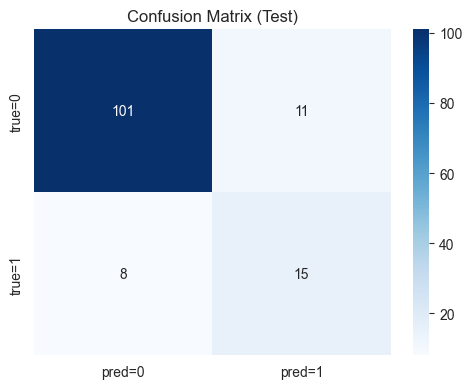

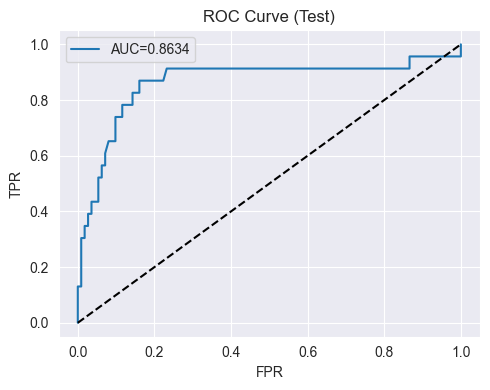

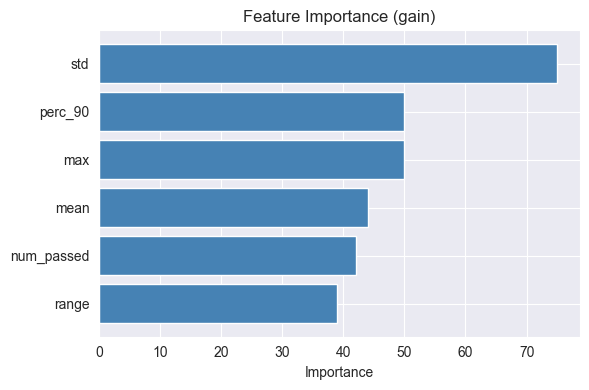


Test AUC:  0.8634
Test F1:   0.6122 (threshold=0.3)

Run ID: cd5cfdc8b72f475298e4f5b8235fbddd
MLflow UI: http://localhost:5050/#/experiments
🏃 View run final_lgbm_balanced at: http://localhost:5050/#/experiments/1/runs/cd5cfdc8b72f475298e4f5b8235fbddd
🧪 View experiment at: http://localhost:5050/#/experiments/1


In [25]:
with mlflow.start_run(run_name=f'final_{BEST_MODEL_NAME}') as run:
    RUN_ID = run.info.run_id
    print(f'Run ID: {RUN_ID}')

    mlflow.set_tag('model_type', 'LGBMClassifier')
    mlflow.set_tag('boosting_type', BEST_PARAMS.get('boosting_type', 'gbdt'))
    mlflow.set_tag('dataset', 'merged_for_boosting.csv')
    mlflow.set_tag('features', ','.join(FEATURES))
    mlflow.set_tag('selected_as', BEST_MODEL_NAME)
    mlflow.set_tag('stage', 'final')

    mlflow.log_param('seed', SEED)
    mlflow.log_param('test_size', 0.15)
    mlflow.log_param('val_size', 0.15)
    mlflow.log_param('n_train', len(X_train))
    mlflow.log_param('n_val', len(X_val))
    mlflow.log_param('n_test', len(X_test))
    mlflow.log_param('class_imbalance_ratio', round(SCALE_POS_WEIGHT, 4))
    mlflow.log_param('decision_threshold', THRESHOLD)
    for k, v in BEST_PARAMS.items():
        mlflow.log_param(k, v)
    for split_name, Xs, ys in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
        proba = final_model.predict_proba(Xs)[:, 1]
        preds = (proba >= THRESHOLD).astype(int)
        mlflow.log_metric(f'{split_name}_auc', roc_auc_score(ys, proba))
        mlflow.log_metric(f'{split_name}_f1', f1_score(ys, preds, zero_division=0))
        mlflow.log_metric(f'{split_name}_accuracy', accuracy_score(ys, preds))
        mlflow.log_metric(f'{split_name}_precision', precision_score(ys, preds, zero_division=0))
        mlflow.log_metric(f'{split_name}_recall', recall_score(ys, preds, zero_division=0))
    try:
        from mlflow.models import infer_signature
        signature = infer_signature(X_train, final_model.predict(X_train))
        mlflow.lightgbm.log_model(
            final_model,
            artifact_path='model',
            signature=signature,
            input_example=X_train.head(3)
        )
    except Exception as e:
        print(f'[warn] log_model пропущен: {e}')

    fig_cm = plot_confusion_matrix(y_test, test_preds, 'Confusion Matrix (Test)')
    mlflow.log_figure(fig_cm, 'plots/confusion_matrix_test.png')
    plt.show()

    fig_roc = plot_roc(y_test, test_proba, 'ROC Curve (Test)')
    mlflow.log_figure(fig_roc, 'plots/roc_curve_test.png')
    plt.show()

    fig_fi = plot_feature_importance(final_model, FEATURES)
    mlflow.log_figure(fig_fi, 'plots/feature_importance.png')
    plt.show()

    sample_preds = X_test.copy()
    sample_preds['y_true'] = y_test.values
    sample_preds['y_pred'] = test_preds
    sample_preds['y_proba'] = test_proba
    sample_preds.to_csv('/tmp/sample_predictions.csv', index=False)
    mlflow.log_artifact('/tmp/sample_predictions.csv', artifact_path='artifacts')

print(f'\nTest AUC:  {roc_auc_score(y_test, test_proba):.4f}')
print(f'Test F1:   {f1_score(y_test, test_preds, zero_division=0):.4f} (threshold={THRESHOLD})')
print(f'\nRun ID: {RUN_ID}')
print(f'MLflow UI: {MLFLOW_URI}/#/experiments')

## 7. Установка тега PRD на финальную модель

In [62]:
client = mlflow.tracking.MlflowClient()

# Снимаем тег PRD со всех предыдущих запусков
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
all_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.deployment = 'PRD'"
)
for old_run in all_runs:
    client.delete_tag(old_run.info.run_id, 'deployment')
    print(f'Снят тег PRD с run {old_run.info.run_id}')

Снят тег PRD с run cd5cfdc8b72f475298e4f5b8235fbddd


In [27]:
client.set_tag(RUN_ID, 'deployment', 'PRD')
client.set_tag(RUN_ID, 'prd_reason',
    f'Best val_auc={best_results["val_auc"]:.4f}, '
    f'test_auc={best_results["test_auc"]:.4f}, '
    f'low overfitting={best_results["overfitting"]:.4f}')

print(f'\nТег PRD установлен на run: {RUN_ID}')
print(f'MLflow UI: {MLFLOW_URI}/#/experiments/{experiment.experiment_id}/runs/{RUN_ID}')


Тег PRD установлен на run: cd5cfdc8b72f475298e4f5b8235fbddd
MLflow UI: http://localhost:5050/#/experiments/1/runs/cd5cfdc8b72f475298e4f5b8235fbddd


## 8. Анализ ошибок модели

In [28]:
errors_df = X_test.copy()
errors_df['y_true'] = y_test.values
errors_df['y_pred'] = test_preds
errors_df['y_proba'] = test_proba
errors_df['error_type'] = ''
errors_df.loc[(errors_df['y_true'] == 1) & (errors_df['y_pred'] == 0), 'error_type'] = 'FN'  # False Negative
errors_df.loc[(errors_df['y_true'] == 0) & (errors_df['y_pred'] == 1), 'error_type'] = 'FP'  # False Positive

error_counts = errors_df['error_type'].value_counts()
print('Распределение ошибок:')
print(error_counts)

Распределение ошибок:
error_type
      116
FP     11
FN      8
Name: count, dtype: int64


### False Negatives (пропущенные релевантные)

In [32]:
fn_cases = errors_df[errors_df['error_type'] == 'FN'].sort_values('y_proba')
print(f'Всего: {len(fn_cases)}')
print(fn_cases.head(10).to_string(index=False))


Всего: 8
     max     mean      std  perc_90  num_passed    range  y_true  y_pred  y_proba error_type
0.243774 0.223886 0.009917 0.240649          13 0.029297       1       0 0.126397         FN
0.238403 0.205835 0.015475 0.226074         108 0.069214       1       0 0.126698         FN
0.241333 0.218027 0.011498 0.231323         122 0.056274       1       0 0.184684         FN
0.266846 0.244543 0.012026 0.260156          40 0.047729       1       0 0.226236         FN
0.254639 0.218397 0.017795 0.239575         115 0.075073       1       0 0.241097         FN
0.253906 0.225417 0.015099 0.243604         115 0.072388       1       0 0.267410         FN
0.269775 0.212208 0.023541 0.246924         103 0.098755       1       0 0.275751         FN
0.244507 0.218805 0.012718 0.233716          98 0.069702       1       0 0.298547         FN


### False Positives (ложные срабатывания) —

In [33]:
fp_cases = errors_df[errors_df['error_type'] == 'FP'].sort_values('y_proba', ascending=False)

print(f'Всего: {len(fp_cases)}')
print(fp_cases.head(10).to_string(index=False))

Всего: 11
     max     mean      std  perc_90  num_passed    range  y_true  y_pred  y_proba error_type
0.249634 0.228320 0.008371 0.237061         537 0.072266       0       1 0.371343         FP
0.292969 0.228748 0.030652 0.277075          42 0.109619       0       1 0.368449         FP
0.269531 0.228198 0.018995 0.256470         116 0.080566       0       1 0.366197         FP
0.269531 0.242026 0.014166 0.257568         187 0.094971       0       1 0.363946         FP
0.267578 0.231002 0.015036 0.247559         129 0.075562       0       1 0.358649         FP
0.275391 0.229354 0.016210 0.247192         192 0.095703       0       1 0.356947         FP
0.279053 0.215737 0.033109 0.266211          28 0.126587       0       1 0.335906         FP
0.256348 0.218041 0.013518 0.233276         239 0.087646       0       1 0.313084         FP
0.262451 0.230583 0.021395 0.257349          32 0.077393       0       1 0.311179         FP
0.267334 0.234273 0.027871 0.262769          18 0.092651    

In [64]:
tp_cases = errors_df[(errors_df['y_true'] == 1) & (errors_df['y_pred'] == 1)]
tp_cases

,max,mean,std,perc_90,num_passed,range,y_true,y_pred,y_proba,error_type
615,0.284424,0.247716,0.026988,0.273877,65,0.105957,1,1,0.375245,
801,0.257812,0.238945,0.021848,0.255371,39,0.078735,1,1,0.311179,
407,0.285156,0.228253,0.026488,0.269678,33,0.103149,1,1,0.365430,
516,0.268799,0.229693,0.020885,0.256274,42,0.086792,1,1,0.316010,
219,0.282471,0.247462,0.027447,0.278174,34,0.089600,1,1,0.362097,
817,0.249146,0.230758,0.010843,0.241394,136,0.069580,1,1,0.369798,
501,0.281250,0.239081,0.019750,0.262891,173,0.095703,1,1,0.385938,
15,0.262207,0.229095,0.018234,0.247620,66,0.075684,1,1,0.356292,
602,0.282715,0.261430,0.018556,0.276978,96,0.095581,1,1,0.386769,
527,0.291748,0.241328,0.021657,0.267725,98,0.102905,1,1,0.370297,


In [65]:
print(f'FN: {len(fn_cases)} случаев, TP: {len(tp_cases)} случаев')

FN: 8 случаев, TP: 15 случаев


1. FN (пропущенные релевантные):
   - Низкий 'max' и 'mean' при релевантности — документ слабо похож на запрос
   - Причина не корректируется: признаки построены на сходстве CLIP-эмбеддингов, и если человек считает документ релевантным по семантике вне визуально домена, признаки этого не уловят.

2. FP (ложные срабатывания):
   - Высокий 'max' при нулевой релевантности — документ визуально похож (высокое косинусное сходство), но семантически не соответствует запросу.
   - Причина не корректируется без добавления текстовых/семантических признаков.

In [66]:
with mlflow.start_run(run_id=RUN_ID):
    errors_df.to_csv('/tmp/error_analysis.csv', index=False)
    mlflow.log_artifact('/tmp/error_analysis.csv', artifact_path='artifacts')
    mlflow.log_metric('test_false_negatives', len(fn_cases))
    mlflow.log_metric('test_false_positives', len(fp_cases))

🏃 View run final_lgbm_balanced at: http://localhost:5050/#/experiments/1/runs/cd5cfdc8b72f475298e4f5b8235fbddd
🧪 View experiment at: http://localhost:5050/#/experiments/1


## 9. Сравнение с baseline

In [67]:
comparison_table = pd.DataFrame([
    {
        'Модель': 'Majority Baseline (всегда 0)',
        'Test AUC': baseline_results['test_auc'],
        'Test F1': baseline_results['test_f1'],
        'Test Accuracy': baseline_results['test_accuracy'],
    },
    {
        'Модель': 'Decision Stump (depth=1)',
        'Test AUC': stump_results['test_auc'],
        'Test F1': stump_results['test_f1'],
        'Test Accuracy': stump_results['test_accuracy'],
    },
    {
        'Модель': f'LightGBM ({BEST_MODEL_NAME}) [ФИНАЛ]',
        'Test AUC': roc_auc_score(y_test, test_proba),
        'Test F1': f1_score(y_test, test_preds, zero_division=0),
        'Test Accuracy': accuracy_score(y_test, test_preds),
    },
])
display(comparison_table)

lgbm_auc = roc_auc_score(y_test, test_proba)
stump_auc = stump_results['test_auc']

,Модель,Test AUC,Test F1,Test Accuracy
0,Majority Baseline (всегда 0),0.500000,0.000000,0.829630
1,Decision Stump (depth=1),0.798719,0.640000,0.866667
2,LightGBM (lgbm_balanced) [ФИНАЛ],0.863354,0.612245,0.859259


Прирост AUC над Decision Stump: +0.0646
Интерпретация: LightGBM существенно превосходит baseline, эффективнее использует нелинейные взаимодействия признаков при дисбалансе классов.

## 10. Проверка устойчивости (Robustness)

In [68]:
def robustness_test(model, X, y, noise_levels=(0.01, 0.05, 0.10), n_trials=5):
    """Добавляем гауссов шум к числовым признакам, смотрим на изменение AUC."""
    base_proba = model.predict_proba(X)[:, 1]
    base_auc = roc_auc_score(y, base_proba)
    results = [{'noise_std': 0.0, 'mean_auc': base_auc, 'std_auc': 0.0, 'auc_drop': 0.0}]

    for noise_std in noise_levels:
        aucs = []
        for _ in range(n_trials):
            X_noisy = X + np.random.normal(0, noise_std * X.std(), X.shape)
            proba = model.predict_proba(X_noisy)[:, 1]
            aucs.append(roc_auc_score(y, proba))
        results.append({
            'noise_std': noise_std,
            'mean_auc': np.mean(aucs),
            'std_auc': np.std(aucs),
            'auc_drop': base_auc - np.mean(aucs)
        })

    return pd.DataFrame(results)

In [69]:
rob_df = robustness_test(final_model, X_test, y_test)
display(rob_df[rob_df['noise_std'] > 0])

,noise_std,mean_auc,std_auc,auc_drop
1,0.01,0.864907,0.001902,-0.001553
2,0.05,0.863082,0.007570,0.000272
3,0.10,0.876087,0.012018,-0.012733


### Логируем robustness-метрики

In [70]:
with mlflow.start_run(run_id=RUN_ID):
    for _, row in rob_df.iterrows():
        if row['noise_std'] > 0:
            key = str(row['noise_std']).replace('.', '_')
            mlflow.log_metric(f'robustness_auc_noise_{key}', row['mean_auc'])
            mlflow.log_metric(f'robustness_drop_noise_{key}', row['auc_drop'])
    rob_df.to_csv('/tmp/robustness_results.csv', index=False)
    mlflow.log_artifact('/tmp/robustness_results.csv', artifact_path='artifacts')

🏃 View run final_lgbm_balanced at: http://localhost:5050/#/experiments/1/runs/cd5cfdc8b72f475298e4f5b8235fbddd
🧪 View experiment at: http://localhost:5050/#/experiments/1


## 11. Итоговый отчёт

In [71]:
train_proba = final_model.predict_proba(X_train)[:, 1]
val_proba   = final_model.predict_proba(X_val)[:, 1]


Финальная модель:   lgbm_balanced

MLflow Run ID:      858443cfbf6c4e10a0b55677380922a5

Тег deployment:     PRD

Decision threshold: 0.3

### Показатели

Train AUC:  0.9881

Val   AUC:  0.8133

Test  AUC:  0.8634

Test  F1:   0.6122 (threshold=0.3)

Baseline (stump) Test AUC: 0.7987

Прирост над baseline: +0.0646
